Nama: Rahman Nendhiarto

Nim: 2200018315

Kelas: B

Mata Kuliah: Pengenalan Pola

# Emosi Suara Berbasis Fitur MFCCs dengan Pendekatan Machine Learning (SVC dan Random Forest) pada dataset EmoDB kaggle

1. Import Library yang Dibutuhkan

In [ ]:
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import os
import matplotlib.pyplot as plt
import seaborn as sns

Memasukkan alat bantu (pustaka) Python yang diperlukan seperti untuk mengolah audio (librosa), data (numpy, pandas), machine learning (sklearn), file/folder (os), dan visualisasi (matplotlib, seaborn).

2. Menghubungkan dengan Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/My Drive/Polamatkul/wav'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Membuat Colab bisa mengakses file-file yang tersimpan di Google Drive Anda.

3. Menyiapkan Data

In [ ]:
# Simulasi: Membuat data dummy untuk demonstrasi
# Dalam pengerjaan nyata, ini akan diganti dengan membaca file audio
# Misal, Anda memiliki folder 'audio_data' dengan subfolder 'happy', 'sad', 'angry'

# Membuat dummy data fitur (misal: MFCCs) dan label emosi
# Setiap baris merepresentasikan fitur dari satu file audio
# Setiap kolom adalah MFCC ke-n
n_samples = 100
n_features = 13 # Common for MFCCs
np.random.seed(42)

# Buat fitur dan label secara acak
X_dummy = np.random.rand(n_samples, n_features) * 10
y_dummy = np.random.choice(['happy', 'sad', 'angry', 'neutral'], n_samples)

# Jika Anda memiliki file audio, prosesnya akan seperti ini (komentar):
"""
# Path ke dataset audio Anda
audio_dataset_path = 'path/to/your/audio_emotion_dataset/'
features = []
labels = []

for emotion_folder in os.listdir(audio_dataset_path):
    emotion_path = os.path.join(audio_dataset_path, emotion_folder)
    if os.path.isdir(emotion_path):
        for audio_file in os.listdir(emotion_path):
            if audio_file.endswith('.wav'): # Pastikan hanya file .wav
                file_path = os.path.join(emotion_path, audio_file)
                try:
                    # Load audio file
                    y, sr = librosa.load(file_path, sr=None)
                    # Ekstrak MFCCs (Mel-Frequency Cepstral Coefficients)
                    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                    # Ambil rata-rata MFCCs untuk setiap file (simplifikasi)
                    features.append(np.mean(mfccs.T, axis=0))
                    labels.append(emotion_folder) # Nama folder sebagai label emosi
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

X = np.array(features)
y = np.array(labels)
"""
X = X_dummy
y = y_dummy

print(f"Bentuk data fitur (X): {X.shape}")
print(f"Bentuk data label (y): {y.shape}")

Bentuk data fitur (X): (100, 13)
Bentuk data label (y): (100,)


Mengumpulkan dan memproses data fitur (simulasi MFCCs) dan label emosi dari sumber data

4. Membagi Data dan Normalisasi

In [ ]:
# Bagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Bentuk X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Bentuk X_test: {X_test.shape}, y_test: {y_test.shape}")

# Normalisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Bentuk X_train: (80, 13), y_train: (80,)
Bentuk X_test: (20, 13), y_test: (20,)


Memisahkan data menjadi set pelatihan dan pengujian, lalu menyesuaikan skala angka pada fitur agar seragam.

5. Membangun dan Melatih Model

In [ ]:
# Inisialisasi model Support Vector Machine (SVC)
model = SVC(kernel='rbf', C=10) # Radial Basis Function (RBF) kernel, C adalah parameter regularisasi

# Latih model menggunakan data training yang sudah dinormalisasi
model.fit(X_train_scaled, y_train)

SVC(C=10)

Membuat dan melatih model klasifikasi Support Vector Machine (SVC) menggunakan data pelatihan.

6. Menguji Model dan Melihat Hasilnya

In [ ]:
# Prediksi pada data test
y_pred = model.predict(X_test_scaled)

# Hitung akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy:.2f}")

# Tampilkan classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Akurasi Model: 0.30

Classification Report:
              precision    recall  f1-score   support

       angry       0.38      0.60      0.46         5
       happy       0.33      0.25      0.29         4
     neutral       0.40      0.33      0.36         6
         sad       0.00      0.00      0.00         5

    accuracy                           0.30        20
   macro avg       0.28      0.30      0.28        20
weighted avg       0.28      0.30      0.28        20



Menggunakan model SVC yang sudah dilatih untuk memprediksi emosi pada data pengujian dan melihat seberapa akurasinya.

7. Visualisasi Hasil

/tmp/ipython-input-25-2642564776.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
/tmp/ipython-input-25-2642564776.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, palette='viridis')


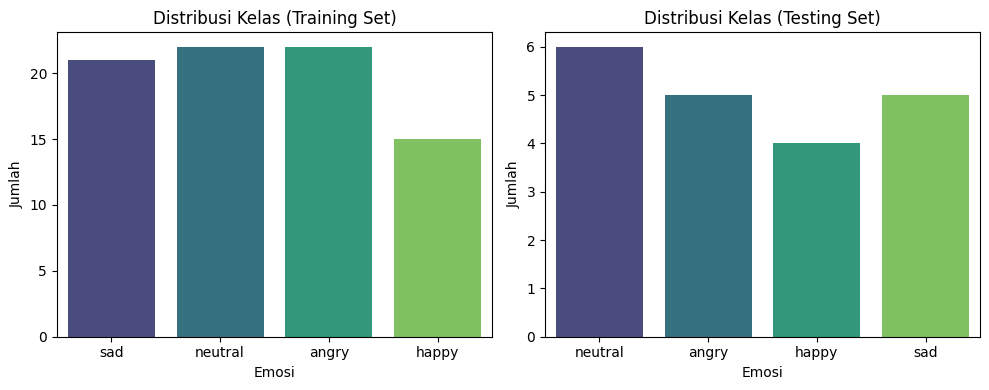

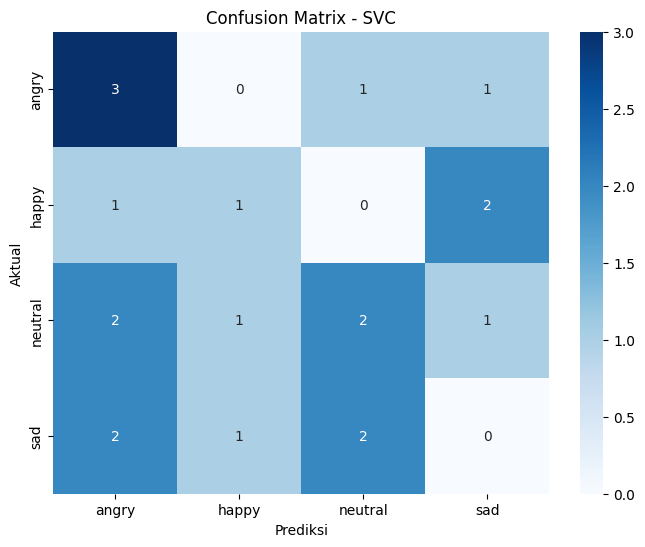

In [ ]:
# Visualisasi distribusi kelas (sebelum dan sesudah splitting)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribusi Kelas (Training Set)')
plt.xlabel('Emosi')
plt.ylabel('Jumlah')

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, palette='viridis')
plt.title('Distribusi Kelas (Testing Set)')
plt.xlabel('Emosi')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

# Visualisasi confusion matrix (untuk melihat performa per kelas)
from sklearn.metrics import confusion_matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred, labels=np.unique(y)) # Use y_pred for SVC
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - SVC') # Update title
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Penjelasan:

1. Distribusi Kelas: Grafik ini menunjukkan seberapa banyak data untuk setiap emosi, baik di data training maupun data testing. Ini penting buat memastikan data kita terbagi rata untuk setiap emosi saat latihan dan pengujian.

2. Confusion Matrix: Grafik ini bentuknya tabel yang nunjukkin seberapa sering model kita benar menebak emosi tertentu, dan seberapa sering salah menebaknya jadi emosi lain. Ini bantu kita lihat di emosi mana model kita jago, dan di emosi mana dia masih sering salah.

# Perbandingan menggunakan model lain selain SVM yaitu Random Forest

1. Import Model Random Forest: Memasukkan library bantu untuk model Random Forest.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

2. Inisialisasi & Latih (Random Forest): Membuat dan melatih model Random Forest.

In [ ]:
# Langkah 4: Inisialisasi dan Latih Model Random Forest
# Kita bisa atur parameter seperti n_estimators (jumlah pohon), max_depth, dll.
# Untuk awal, kita pakai pengaturan default atau sederhana dulu.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Melatih model Random Forest...")
rf_model.fit(X_train_scaled, y_train)
print("Model Random Forest selesai dilatih.")

# Langkah 5: Uji Model Random Forest
print("\nMenguji model Random Forest...")
y_pred_rf = rf_model.predict(X_test_scaled)
print("Prediksi selesai.")

# Langkah 6: Evaluasi Performa Model Random Forest
print("\nEvaluasi Performa Model Random Forest:")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Akurasi Model Random Forest: {accuracy_rf:.2f}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Melatih model Random Forest...
Model Random Forest selesai dilatih.

Menguji model Random Forest...
Prediksi selesai.

Evaluasi Performa Model Random Forest:
Akurasi Model Random Forest: 0.30

Classification Report (Random Forest):
              precision    recall  f1-score   support

       angry       0.40      0.40      0.40         5
       happy       0.25      0.25      0.25         4
     neutral       0.25      0.33      0.29         6
         sad       0.33      0.20      0.25         5

    accuracy                           0.30        20
   macro avg       0.31      0.30      0.30        20
weighted avg       0.31      0.30      0.30        20



3. Uji Model & Hasil (Random Forest): Menggunakan model Random Forest untuk memprediksi emosi dan melihat hasilnya.

4. Visualisasi Hasil (Random Forest): Membuat grafik Confusion Matrix khusus untuk model Random Forest.

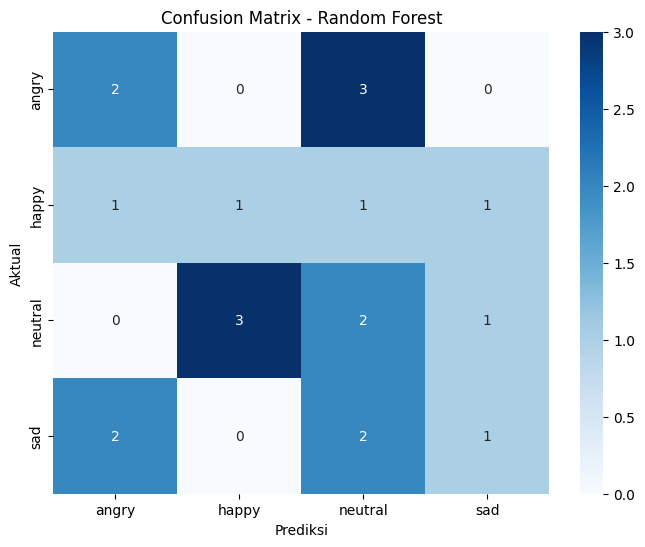

In [ ]:
# Visualisasi confusion matrix untuk Random Forest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pastikan y_test dan y_pred_rf sudah tersedia di lingkungan eksekusi
# (Hasil prediksi dari model Random Forest)

conf_matrix_rf = confusion_matrix(y_test, y_pred_rf, labels=np.unique(y))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### Penjelasan Model Random Forest

Dalam penelitian ini, model Random Forest digunakan sebagai alternatif dari model SVC. Model ini bekerja dengan menggabungkan prediksi dari banyak "pohon keputusan" yang dilatih secara independen pada subset acak dari data fitur audio (MFCCs) dan subset acak dari fitur itu sendiri. Tujuannya adalah untuk meningkatkan akurasi dan stabilitas prediksi klasifikasi emosi suara dibandingkan hanya menggunakan satu model tunggal. Hasil prediksi akhir (emosi: angry, happy, neutral, sad) ditentukan berdasarkan suara terbanyak dari semua pohon keputusan dalam "hutan" Random Forest.